In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, hypergeom
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure,
    precision_score, recall_score, f1_score, silhouette_score,
)

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False

sys.path.append('../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS         = 5
NUM_EPOCHS     = 600
VALIDATE_EVERY = 50
BATCH_SIZE     = 4096
LATENT_DIM     = 16
PATIENCE       = 20
N_CLUSTERS     = 10
RESULTS_DIR    = "results/reproducibility"

# SHERLOCK_KWARGS = {
#     # "tau_end": 0.3,
#     # # "tau_init": 1.5,
#     # "cov_lambda": 1e-5,
#     # "H_lambda": 1e-1,
#     # "gate_row_repulsion_lambda": 1e-2,
#     # "ce_lambda": 10,
#     # "shift": "linear",
#     "l0_lambda": 3,
#     "debug": True,
#     # "lr": 1e-3,
#     # "ntc_lambda": 1e-5,
#     # "pert_lambda": 1,
# }

SHERLOCK_KWARGS = {
    "l0_lambda": 8.5,
    "ce_lambda": 20.0,
    "n_epochs_kl_warmup": 300.0,
    "n_epochs_l0_warmup": 350.0,
    "tau_end": 0.25,
    "rank": 8,
}

os.makedirs(f"{RESULTS_DIR}/figures", exist_ok=True)
print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/reproducibility


## Data loading

In [4]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|████████████████████████████████████████████████████████████████████████| 681/681 [00:10<00:00, 66.69it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for cluster evaluation

In [5]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

# Flat table for merging (gene, pathway)
pathways_flat = pathway_df_indexed.reset_index()

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Cluster alignment helper

In [6]:
def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
    gene_embeddings=None,
    knn_k: int = 5,
    linear_probe_cv: int = 5,
):
    """Hungarian-match predicted clusters to ground-truth pathways.
    
    Embedding metrics (silhouette macro, kNN purity, linear probe) are
    computed via slk.tl.compute_embedding_metrics when gene_embeddings is provided.
    """
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col, how="inner", validate="one_to_one",
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    if min_pathway_size > 1:
        keep = df[pathway_col].value_counts()
        df = df[df[pathway_col].isin(keep[keep >= min_pathway_size].index)].copy()

    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    mapped   = np.array([mapping.get(cl) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy  = float(is_match.mean())
    precision = precision_score(y_true, mapped, average="macro", zero_division=0)
    recall    = recall_score(y_true, mapped, average="macro", zero_division=0)
    f1        = f1_score(y_true, mapped, average="macro", zero_division=0)
    ari       = adjusted_rand_score(y_true, y_pred)
    ami       = adjusted_mutual_info_score(y_true, y_pred)
    hom, com, vmeas = homogeneity_completeness_v_measure(y_true, y_pred)

    # Embedding-based metrics via shared helper
    sil = knn_pur = lin_probe = None
    if gene_embeddings is not None:
        emb = gene_embeddings.loc[df[gene_col].values].values
        emb_metrics = slk.tl.compute_embedding_metrics(
            emb, y_true, knn_k=knn_k, linear_probe_cv=linear_probe_cv
        )
        sil       = emb_metrics["silhouette"]
        knn_pur   = emb_metrics["knn_purity"]
        lin_probe = emb_metrics["linear_probe"]

    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        pur = (g[pathway_col] == majority).mean()
        rec_cl = (g[pathway_col] == majority).sum() / max((df[pathway_col] == majority).sum(), 1)
        purity_rows.append({"cluster": str(cl), "size": len(g),
                             "mapped_pathway": mapping.get(str(cl)), "purity": pur, "recall": rec_cl})
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    contingency = contingency_df.copy()
    row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    N_total = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes   = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            pval = hypergeom.sf(k - 1, N_total, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K,
                             "n": n, "N": N_total, "pval": float(pval)})
    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * max(len(enrich_df), 1), 1.0)
    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    df["mapped_pathway"] = mapped
    df["is_match"]       = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}),
        "mapping": mapping,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "ari": ari, "ami": ami,
        "homogeneity": hom, "completeness": com, "v_measure": vmeas,
        "silhouette": sil, "knn_purity": knn_pur, "linear_probe": lin_probe,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": row_norm,
        "contingency_col_norm": col_norm,
        "enrichment": enrich_df,
    }

## Reproducibility loop

Train Sherlock `N_RUNS` times independently. After each run extract:
- **W** — the (P × d) gate matrix from `model.gate(deterministic=True)`
- **rho_corr** — the (P × P) learned covariance correlation matrix
- **clusters** — hierarchical cut on the pathway-gene subset of rho_corr, then Hungarian-matched to pathways via `align_and_summarize`

In [8]:
import gc
import os
import pickle
import torch
import numpy as np
import pandas as pd

# Path to store aggregate loop statistics
SHERLOCK_METRICS_CSV = f"{RESULTS_DIR}/sherlock_per_run_metrics.csv"
os.makedirs(f"{RESULTS_DIR}/models", exist_ok=True)

# 1. Load existing metrics if resuming from a crash
if os.path.exists(SHERLOCK_METRICS_CSV):
    print(f"Found existing run metrics. Loading {SHERLOCK_METRICS_CSV}...")
    metrics_df = pd.read_csv(SHERLOCK_METRICS_CSV)
    per_run_metrics = metrics_df.to_dict(orient='records')
else:
    per_run_metrics = []

for run in range(N_RUNS):
    print(f"\n{'='*50}\nSherlock run {run + 1}/{N_RUNS}\n{'='*50}")

    # Unique file path for this run's heavy arrays/results
    run_details_path = f"{RESULTS_DIR}/models/sherlock_run_details_{run}.pkl"
    
    # Check if this run is completely finished on disk
    already_run = any(r['run'] == (run + 1) for r in per_run_metrics)
    
    if already_run and os.path.exists(run_details_path):
        print(f"  -> [RESUMING] Found completed results for run {run + 1}. Skipping computation.")
        # Print out the cached stats so you can still see them in the terminal
        m = next(r for r in per_run_metrics if r['run'] == (run + 1))
        sil_str = f"  sil={m['silhouette']:.3f}" if pd.notna(m['silhouette']) else ""
        knn_str = f"  knn={m['knn_purity']:.3f}" if pd.notna(m['knn_purity']) else ""
        lp_str  = f"  lp={m['linear_probe']:.3f}" if pd.notna(m['linear_probe']) else ""
        print(f"  accuracy={m['accuracy']:.3f}  f1={m['f1']:.3f}  ari={m['ari']:.3f}  ami={m['ami']:.3f}{sil_str}{knn_str}{lp_str}  cf_ate_r={m['cf_ate_pearson_r']:.3f}")
        continue

    # --- Fresh Execution ---
    out = slk.tl.run(
        data,
        model="vae",
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        device=DEVICE,
        latent_dim=LATENT_DIM,
        patience=PATIENCE,
        validate_every=VALIDATE_EVERY,
        seed=run,
        **SHERLOCK_KWARGS,
    )
    model = out['model']

    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)
    results = data.uns['results']

    # Gate matrix W: (P, d)
    W = model.gate(deterministic=True).detach().cpu().numpy()

    # Learned covariance correlation
    rho_corr  = np.asarray(results['z_corr'], dtype=float)
    rho_perts = np.asarray(results['z_perts'])

    # Pathway-gene subset and clustering
    pert_to_idx = {name: i for i, name in enumerate(rho_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = rho_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    raw_clusters = slk.tl.cluster_rho(
        data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False
    )

    # Gene embeddings from rho_embed
    rho_embed = results.get('rho_embed')
    gene_embeddings = None
    if rho_embed is not None:
        gene_embeddings = pd.DataFrame(
            np.asarray(rho_embed)[gene_ids],
            index=valid_genes,
        )

    # Hungarian-match cluster labels to pathway names
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': raw_clusters})
    align_out   = align_and_summarize(clusters_df, pathways_flat, gene_embeddings=gene_embeddings)

    merged = align_out['merged'].set_index('gene')
    mapped_pathway = np.array(
        [merged.loc[g, 'mapped_pathway'] if g in merged.index else None
         for g in valid_genes],
        dtype=object,
    )

    # Counterfactual ATE
    ate_metrics = slk.tl.compute_cf_ate_metrics(model, data, treat_effect_adata)

    detailed_run_data = {
        'run':            run,
        'W':              W,
        'rho_corr':       rho_corr,
        'rho_perts':      rho_perts,
        'valid_genes':    valid_genes,
        'raw_clusters':   raw_clusters,
        'mapped_pathway': mapped_pathway,
        'align_out':      align_out,
    }
    with open(run_details_path, 'wb') as f:
        pickle.dump(detailed_run_data, f)

    # 3. Save light stats to records
    m = align_out
    metrics_entry = {
        'run':              run + 1,
        'accuracy':         m['accuracy'],
        'precision':        m['precision'],
        'recall':           m['recall'],
        'f1':               m['f1'],
        'ari':              m['ari'],
        'ami':              m['ami'],
        'homogeneity':      m['homogeneity'],
        'completeness':     m['completeness'],
        'v_measure':        m['v_measure'],
        'silhouette':       m['silhouette'],
        'knn_purity':       m['knn_purity'],
        'linear_probe':     m['linear_probe'],
        'cf_ate_pearson_r': ate_metrics['cf_ate_pearson_r'],
    }
    
    per_run_metrics = [r for r in per_run_metrics if r['run'] != (run + 1)]
    per_run_metrics.append(metrics_entry)
    pd.DataFrame(per_run_metrics).to_csv(SHERLOCK_METRICS_CSV, index=False)

    # Print out results
    sil_str = f"  sil={m['silhouette']:.3f}" if m['silhouette'] is not None else ""
    knn_str = f"  knn={m['knn_purity']:.3f}" if m['knn_purity'] is not None else ""
    lp_str  = f"  lp={m['linear_probe']:.3f}" if m['linear_probe'] is not None else ""
    ate_val = ate_metrics['cf_ate_pearson_r']
    ate_str = f"  cf_ate_r={ate_val:.3f}" if np.isfinite(ate_val) else "  cf_ate_r=N/A"
    print(f"  accuracy={m['accuracy']:.3f}  f1={m['f1']:.3f}  ari={m['ari']:.3f}  ami={m['ami']:.3f}{sil_str}{knn_str}{lp_str}{ate_str}")

    if 'out' in locals(): del out
    if 'model' in locals(): del model
    torch.cuda.empty_cache()
    gc.collect()

print("\nAll runs complete.")


Sherlock run 1/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

  accuracy=0.988  f1=0.989  ari=0.799  ami=0.922  sil=0.244  knn=0.846  lp=0.907  cf_ate_r=0.581

Sherlock run 2/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

  accuracy=0.997  f1=0.996  ari=0.956  ami=0.968  sil=0.226  knn=0.839  lp=0.881  cf_ate_r=0.555

Sherlock run 3/5
Training VAE on cuda …


...

  accuracy=0.994  f1=0.993  ari=0.952  ami=0.955  sil=0.227  knn=0.816  lp=0.875  cf_ate_r=0.588

Sherlock run 4/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

  accuracy=0.976  f1=0.979  ari=0.884  ami=0.916  sil=0.259  knn=0.854  lp=0.910  cf_ate_r=0.625

Sherlock run 5/5
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

  accuracy=0.997  f1=0.998  ari=0.938  ami=0.952  sil=0.215  knn=0.836  lp=0.884  cf_ate_r=0.573

All runs complete.


## Per-run clustering metrics

In [9]:
print("Loading detailed arrays back into 'run_results' for downstream code...")
run_results = []
for run in range(N_RUNS):
    run_details_path = f"{RESULTS_DIR}/models/sherlock_run_details_{run}.pkl"
    if os.path.exists(run_details_path):
        with open(run_details_path, 'rb') as f:
            run_results.append(pickle.load(f))

# Re-establish your exact expected metrics dataframe structure
metrics_df = pd.DataFrame(per_run_metrics).set_index('run').sort_index()
print("\n" + metrics_df.round(4).to_string())

print("\nMean ± Std:")
for col in metrics_df.columns:
    v = pd.to_numeric(metrics_df[col], errors='coerce').dropna().values
    if len(v) > 0:
        print(f"  {col:15s}: {np.mean(v):.4f} ± {np.std(v):.4f}")
    else:
        print(f"  {col:15s}: N/A")

Loading detailed arrays back into 'run_results' for downstream code...

     accuracy  precision  recall      f1     ari     ami  homogeneity  completeness  v_measure  silhouette  knn_purity  linear_probe  cf_ate_pearson_r
run                                                                                                                                                   
1      0.9881     0.9865  0.9916  0.9886  0.7986  0.9217       0.9880        0.8706     0.9256      0.2445      0.8460        0.9075            0.5805
2      0.9970     0.9977  0.9952  0.9964  0.9565  0.9684       0.9925        0.9486     0.9700      0.2255      0.8388        0.8806            0.5550
3      0.9940     0.9955  0.9914  0.9933  0.9523  0.9546       0.9915        0.9248     0.9570      0.2267      0.8161        0.8746            0.5883
4      0.9761     0.9859  0.9730  0.9789  0.8842  0.9160       0.9597        0.8841     0.9203      0.2593      0.8543        0.9104            0.6250
5      0.9970     0.99

## Pairwise similarity metrics

For each pair of runs compute:

1. **W correlation** — Pearson r between upper triangles of `W @ Wᵀ` (co-activation matrices, invariant to latent-dim permutation).

2. **Covariance correlation** — Pearson r between upper triangles of `rho_corr`.

3. **Cluster Jaccard (defined)** — Jaccard co-membership similarity using the raw hierarchical cluster integer labels (permutation-invariant by construction).

4. **Cluster Jaccard (matched)** — Same co-membership Jaccard but using the **Hungarian-matched** pathway labels, so identical names mean the same pathway in both runs.
   $$J = \frac{|\{(i,j): \text{same label in both runs}\}|}{|\{(i,j): \text{same label in at least one run}\}|}$$

In [10]:
def _jaccard_comembership(labels_i, labels_j):
    """Jaccard similarity of pairwise co-membership indicators."""
    n = len(labels_i)
    same_i = labels_i[:, None] == labels_i[None, :]
    same_j = labels_j[:, None] == labels_j[None, :]
    triu   = np.triu_indices(n, k=1)
    a, b   = same_i[triu], same_j[triu]
    union  = int((a | b).sum())
    return int((a & b).sum()) / union if union > 0 else np.nan


pairs = list(combinations(range(N_RUNS), 2))

w_corrs           = []
cov_corrs         = []
jaccard_defined   = []
jaccard_matched   = []

for i, j in pairs:
    ri, rj = run_results[i], run_results[j]

    # --- W co-activation correlation ---
    Wi, Wj = ri['W'], rj['W']
    Ci = Wi @ Wi.T
    Cj = Wj @ Wj.T
    triu = np.triu_indices(Ci.shape[0], k=1)
    r_W, _ = pearsonr(Ci[triu], Cj[triu])
    w_corrs.append(r_W)

    # --- rho_corr correlation ---
    rho_i, rho_j = ri['rho_corr'], rj['rho_corr']
    triu_rho = np.triu_indices(rho_i.shape[0], k=1)
    fi, fj   = rho_i[triu_rho], rho_j[triu_rho]
    valid    = np.isfinite(fi) & np.isfinite(fj)
    r_cov, _ = pearsonr(fi[valid], fj[valid])
    cov_corrs.append(r_cov)

    # --- Jaccard (defined): raw hierarchical cluster integers ---
    cl_i = ri['raw_clusters'].astype(object)
    cl_j = rj['raw_clusters'].astype(object)
    jaccard_defined.append(_jaccard_comembership(cl_i, cl_j))

    # --- Jaccard (matched): Hungarian-matched pathway labels ---
    genes_i = ri['valid_genes']
    genes_j = rj['valid_genes']
    common  = [g for g in genes_i if g in set(genes_j)]

    gi_idx = {g: k for k, g in enumerate(genes_i)}
    gj_idx = {g: k for k, g in enumerate(genes_j)}

    mp_i = np.array([ri['mapped_pathway'][gi_idx[g]] for g in common], dtype=object)
    mp_j = np.array([rj['mapped_pathway'][gj_idx[g]] for g in common], dtype=object)

    both_valid = np.array([a is not None and b is not None for a, b in zip(mp_i, mp_j)])
    mp_i = mp_i[both_valid]
    mp_j = mp_j[both_valid]
    jaccard_matched.append(_jaccard_comembership(mp_i, mp_j))

pair_labels = [f"run{i+1}–run{j+1}" for i, j in pairs]

summary_df = pd.DataFrame({
    'pair':               pair_labels,
    'W_coact_pearson_r':  w_corrs,
    'rho_corr_pearson_r': cov_corrs,
    'cluster_jaccard_defined': jaccard_defined,
    'cluster_jaccard_matched': jaccard_matched,
})

print(summary_df.to_string(index=False))
print("\nMean ± Std across pairs:")
for col in ['W_coact_pearson_r', 'rho_corr_pearson_r', 'cluster_jaccard_defined', 'cluster_jaccard_matched']:
    vals = summary_df[col].dropna().values
    print(f"  {col:30s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

     pair  W_coact_pearson_r  rho_corr_pearson_r  cluster_jaccard_defined  cluster_jaccard_matched
run1–run2           0.954345            0.801040                 0.706464                 0.950114
run1–run3           0.955978            0.857712                 0.658171                 0.941742
run1–run4           0.962411            0.844933                 0.691150                 0.867448
run1–run5           0.957816            0.860955                 0.630366                 0.942609
run2–run3           0.949664            0.730853                 0.882070                 0.973833
run2–run4           0.957002            0.814531                 0.848540                 0.909992
run2–run5           0.950957            0.760537                 0.841557                 0.975107
run3–run4           0.949052            0.801471                 0.784687                 0.908107
run3–run5           0.952901            0.848657                 0.839455                 0.965878
run4–run5 

## Visualisation

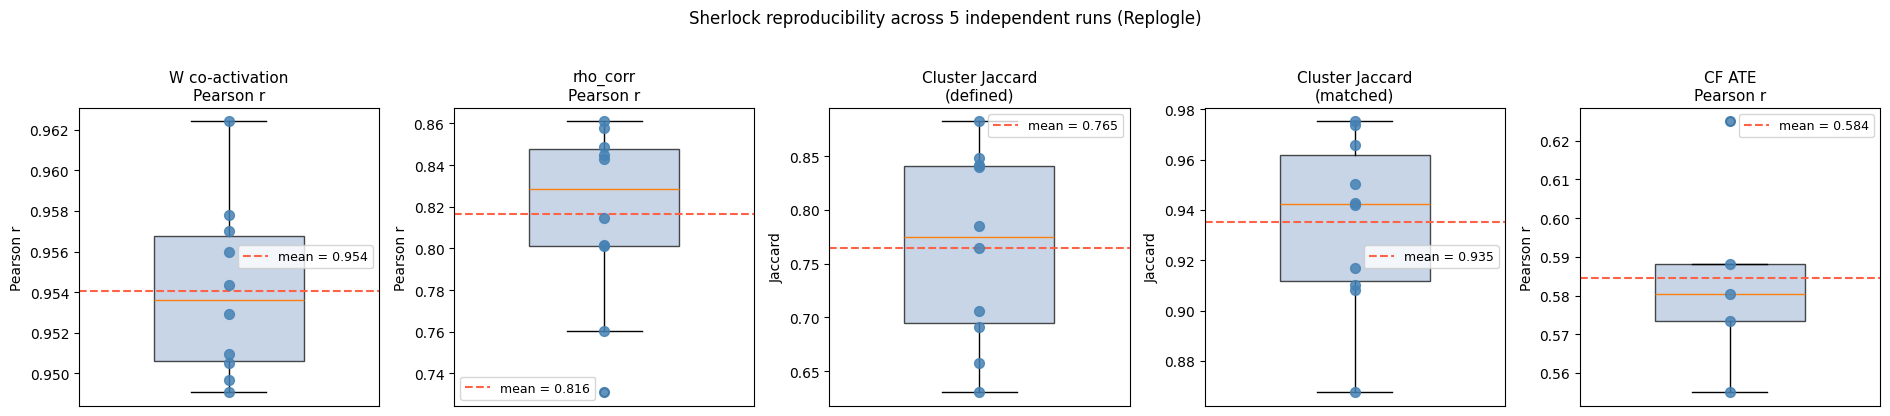

In [11]:
ate_values = pd.to_numeric(metrics_df['cf_ate_pearson_r'], errors='coerce').dropna().tolist()

metric_info = [
    (w_corrs,         'W co-activation\nPearson r',   'Pearson r'),
    (cov_corrs,       'rho_corr\nPearson r',           'Pearson r'),
    (jaccard_defined, 'Cluster Jaccard\n(defined)',    'Jaccard'),
    (jaccard_matched, 'Cluster Jaccard\n(matched)',    'Jaccard'),
    (ate_values,      'CF ATE\nPearson r',             'Pearson r'),
]

fig, axes = plt.subplots(1, 5, figsize=(19, 4))

for ax, (values, title, ylabel) in zip(axes, metric_info):
    clean = [v for v in values if np.isfinite(v)]
    ax.boxplot(clean, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
    ax.scatter([1] * len(clean), clean, color='steelblue', s=50, zorder=3, alpha=0.85)
    m = np.mean(clean)
    ax.axhline(m, color='tomato', linestyle='--', linewidth=1.5, label=f'mean = {m:.3f}')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_xlim(0.5, 1.5)
    ax.legend(fontsize=9)

fig.suptitle(f'Sherlock reproducibility across {N_RUNS} independent runs (Replogle)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_boxplots.png', bbox_inches='tight')
plt.show()

## Pairwise heatmaps

Show the full N×N grid of pairwise similarities as heatmaps.

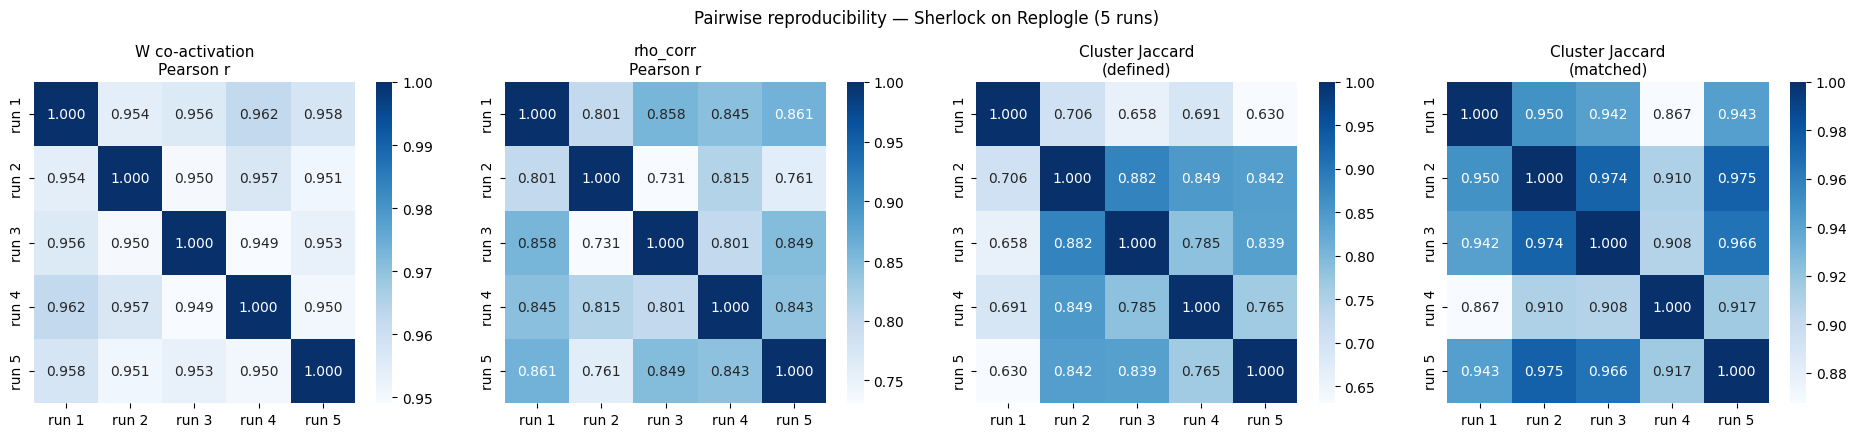

In [12]:
def to_matrix(values, n_runs, pairs):
    M = np.full((n_runs, n_runs), np.nan)
    np.fill_diagonal(M, 1.0)
    for (i, j), v in zip(pairs, values):
        M[i, j] = v
        M[j, i] = v
    return M

W_mat  = to_matrix(w_corrs,         N_RUNS, pairs)
C_mat  = to_matrix(cov_corrs,       N_RUNS, pairs)
Jd_mat = to_matrix(jaccard_defined, N_RUNS, pairs)
Jm_mat = to_matrix(jaccard_matched, N_RUNS, pairs)

run_labels = [f"run {k+1}" for k in range(N_RUNS)]

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

for ax, mat, title in zip(
    axes,
    [W_mat, C_mat, Jd_mat, Jm_mat],
    ['W co-activation\nPearson r', 'rho_corr\nPearson r',
     'Cluster Jaccard\n(defined)', 'Cluster Jaccard\n(matched)'],
):
    off_diag = mat[~np.eye(N_RUNS, dtype=bool)]
    vmin = np.nanmin(off_diag)
    sns.heatmap(
        mat, ax=ax, annot=True, fmt='.3f',
        vmin=vmin, vmax=1.0, cmap='Blues',
        xticklabels=run_labels, yticklabels=run_labels, square=True,
    )
    ax.set_title(title, fontsize=11)

plt.suptitle(f'Pairwise reproducibility — Sherlock on Replogle ({N_RUNS} runs)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_heatmaps.png', bbox_inches='tight')
plt.show()